In [1]:
import pandas as pd
import numpy as np

In [3]:
chunksize = 10 ** 5

In [5]:
train_df = pd.DataFrame()

In [9]:
for chunk in pd.read_csv("/Users/prathikraju/Documents/Machine Learning /Credit risk project/Credit risk project data/train_data.csv", chunksize = chunksize):
    train_df = pd.concat([train_df, chunk])

In [11]:
train_df.shape

(5531451, 190)

In [13]:
train_df.isna().sum()*100/len(train_df)

customer_ID     0.000000
S_2             0.000000
P_2             0.831337
D_39            0.000000
B_1             0.000000
                 ...    
D_141           1.835829
D_142          82.926577
D_143           1.835829
D_144           0.736281
D_145           1.835829
Length: 190, dtype: float64

In [15]:
train_df.head(10)

,customer_ID,S_2,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,...,D_136,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-03-09,0.938469,0.001733,0.008724,1.006838,0.009228,0.124035,0.008771,0.004709,...,NaN,NaN,NaN,0.002427,0.003706,0.003818,NaN,0.000569,0.000610,0.002674
1,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-04-07,0.936665,0.005775,0.004923,1.000653,0.006151,0.126750,0.000798,0.002714,...,NaN,NaN,NaN,0.003954,0.003167,0.005032,NaN,0.009576,0.005492,0.009217
2,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-05-28,0.954180,0.091505,0.021655,1.009672,0.006815,0.123977,0.007598,0.009423,...,NaN,NaN,NaN,0.003269,0.007329,0.000427,NaN,0.003429,0.006986,0.002603
3,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-06-13,0.960384,0.002455,0.013683,1.002700,0.001373,0.117169,0.000685,0.005531,...,NaN,NaN,NaN,0.006117,0.004516,0.003200,NaN,0.008419,0.006527,0.009600
4,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-07-16,0.947248,0.002483,0.015193,1.000727,0.007605,0.117325,0.004653,0.009312,...,NaN,NaN,NaN,0.003671,0.004946,0.008889,NaN,0.001670,0.008126,0.009827
5,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-08-04,0.945964,0.001746,0.007863,1.005006,0.004220,0.110946,0.009857,0.009866,...,NaN,NaN,NaN,0.001924,0.008598,0.004529,NaN,0.000674,0.002223,0.002884
6,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-09-18,0.940705,0.002183,0.018859,1.008024,0.004509,0.103329,0.006603,0.000783,...,NaN,NaN,NaN,0.001336,0.004361,0.009387,NaN,0.007727,0.007661,0.002225
7,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-10-08,0.914767,0.003029,0.014324,1.000242,0.000263,0.108115,0.009527,0.007836,...,NaN,NaN,NaN,0.002397,0.008452,0.005553,NaN,0.001831,0.009616,0.007385
8,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-11-20,0.950845,0.009896,0.016888,1.003995,0.001789,0.102792,0.002519,0.009817,...,NaN,NaN,NaN,0.009742,0.003968,0.007945,NaN,0.008722,0.004369,0.000995
9,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-12-04,0.868580,0.001082,0.001930,1.007504,0.001772,0.100470,0.004626,0.006073,...,NaN,NaN,NaN,0.003611,0.009607,0.007266,NaN,0.008763,0.004753,0.009068


In [19]:
train_label = pd.read_csv("/Users/prathikraju/Documents/Machine Learning /Credit risk project/Credit risk project data/train_labels.csv")

In [21]:
train_label.shape

(458913, 2)

In [23]:
train_lables = train_label.sample(frac = 0.2, random_state = 42)

In [25]:
del train_label

In [27]:
train_labels = train_lables

In [29]:
del train_lables

In [31]:
train_labels.shape

(91783, 2)

In [33]:
train_labels.head(5)

,customer_ID,target
33412,12c761e40348fa242de0356426fa9547f0feea34d1f57b...,0
350485,c34b0cf3175108892e42e9382e8177847ac15636870604...,1
36829,14aff3c0e0ed2aaaef6deb127f2541b67fdd0002615bfd...,0
444951,f82be644eb90ab65d737b6dfc5de670559fa2ca23c98ea...,0
17537,09dec6d53f0f12db6edcaecbb4d2bddf41f220ba9569d1...,0


In [35]:
train_labels = train_labels.set_index('customer_ID')

In [37]:
train_df = train_df.set_index('customer_ID')

In [39]:
train_m = pd.merge(train_labels, train_df, how = 'inner', on = 'customer_ID')

In [41]:
train_m.shape

(1107082, 190)

In [43]:
train_m.head(5)

,target,S_2,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,...,D_136,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145
customer_ID,,,,,,,,,,,,,,,,,,,,,
12c761e40348fa242de0356426fa9547f0feea34d1f57bf4de9c50e7b236c300,0,2017-03-21,0.628534,0.004250,0.017667,0.815468,0.005736,0.265531,0.005933,0.015981,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12c761e40348fa242de0356426fa9547f0feea34d1f57bf4de9c50e7b236c300,0,2017-04-21,0.669914,0.418321,0.354284,1.000587,0.009774,0.176196,0.007370,0.005623,...,NaN,NaN,NaN,0.003869,0.008332,0.005805,NaN,0.006603,0.007874,0.002185
12c761e40348fa242de0356426fa9547f0feea34d1f57bf4de9c50e7b236c300,0,2017-05-08,0.661933,0.003989,0.244867,1.008683,0.005743,0.169471,0.005953,0.004846,...,NaN,NaN,NaN,0.004872,0.008471,0.006763,NaN,0.009782,0.007285,0.000121
12c761e40348fa242de0356426fa9547f0feea34d1f57bf4de9c50e7b236c300,0,2017-06-14,0.644270,0.009351,0.017799,0.668398,0.003148,0.174020,0.006656,0.013463,...,NaN,NaN,NaN,0.009246,0.009905,0.008673,NaN,0.003927,0.001159,0.000433
12c761e40348fa242de0356426fa9547f0feea34d1f57bf4de9c50e7b236c300,0,2017-07-26,0.688055,0.002832,0.009458,0.779692,0.000870,0.174547,0.009100,0.011599,...,NaN,NaN,NaN,0.004311,0.006488,0.004953,NaN,0.009283,0.003769,0.006124


In [45]:
train_m.to_csv("sample_data.csv", index = False)

In [47]:
train_m.dtypes.value_counts()

float64    185
object       3
int64        2
Name: count, dtype: int64

In [49]:
train_m.select_dtypes(include = 'object').columns.tolist()

['S_2', 'D_63', 'D_64']

In [51]:
train_m.select_dtypes(include = 'int64').columns.tolist()

['target', 'B_31']

In [53]:
train_m['target'].value_counts()

target
0    834188
1    272894
Name: count, dtype: int64

In [55]:
train_m['target'].value_counts(normalize=True)

target
0    0.753502
1    0.246498
Name: proportion, dtype: float64

In [57]:
train_m.isna().mean().sort_values(ascending = False).head(20)

D_87     0.999265
D_88     0.998940
D_108    0.994888
D_111    0.993995
D_110    0.993995
B_39     0.993608
D_73     0.989545
B_42     0.986819
D_134    0.966734
D_138    0.966734
D_135    0.966734
D_136    0.966734
D_137    0.966734
R_9      0.943945
B_29     0.930888
D_106    0.903368
D_132    0.903144
D_49     0.902609
R_26     0.890855
D_66     0.887946
dtype: float64

In [59]:
all_missing = train_m.isna().mean() ==  1

In [61]:
all_missing[all_missing].index.tolist()

[]

In [63]:
train_m['S_2'].min(), train_m['S_2'].max()

('2017-03-01', '2018-03-31')

In [65]:
train_m.sort_values(['customer_ID', 'S_2']).groupby('customer_ID').tail(1)

,target,S_2,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,...,D_136,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145
customer_ID,,,,,,,,,,,,,,,,,,,,,
000098081fde4fd64bc4d503a5d6f86a0aedc425c96f5235f98b0f47c9d7d8d4,0,2018-03-12,0.477116,0.000467,0.009413,1.009217,0.007775,0.267037,0.006128,0.125927,...,NaN,NaN,NaN,0.006010,0.005221,0.000937,NaN,0.009790,0.003703,0.006274
000445609ff2a39d2dd02484899affa5696210a95f6869f26390bd26eeb3b651,0,2018-03-17,0.978897,0.001221,0.006584,0.819623,0.001521,0.177809,0.006464,0.010949,...,NaN,NaN,NaN,0.009010,0.007145,0.005159,NaN,0.000031,0.004060,0.000315
0004837f0c785928a29a6f83f70f4a1c54caec483a773ff4b5b317ac251abda0,0,2018-03-02,0.642295,0.685210,0.429796,0.024450,0.005188,0.221216,0.009708,0.357104,...,NaN,NaN,NaN,0.002107,0.001215,0.003079,NaN,0.003943,0.005832,0.000346
0004ec03ca1ab2adb9aa260c61ba5dce8185e19d3ab704029f989240c733b6d0,0,2018-03-08,0.980221,0.009431,0.028153,1.008633,0.503520,0.130219,0.005540,0.006706,...,NaN,NaN,NaN,0.009336,0.006395,0.000355,NaN,0.001410,0.007432,0.009696
00050d84c6d26e26cd2b18c3eed83d3130c270e2361470ff272f9409103d067f,0,2018-03-22,1.006598,0.119977,0.045083,1.005729,0.007899,0.050511,0.192333,0.007466,...,NaN,NaN,NaN,0.004660,0.001356,0.003087,NaN,0.004812,0.004934,0.007411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fffe2bc02423407e33a607660caeed076d713d8a5ad32321530e92704835da88,1,2018-03-17,0.408619,0.765793,1.150845,0.010803,0.008213,1.169100,0.004637,0.364892,...,NaN,NaN,NaN,0.007866,0.009716,0.005847,NaN,0.009344,0.003953,0.006302
ffff518bb2075e4816ee3fe9f3b152c57fc0e6f01bf7fdd3e5b57cfcbee30286,0,2018-03-22,0.831279,0.033670,0.292360,0.055656,0.006953,NaN,0.005791,0.233078,...,NaN,NaN,NaN,0.004393,0.006185,0.001480,NaN,0.004794,0.009230,0.006435
ffff9984b999fccb2b6127635ed0736dda94e544e67e026eee4d20f680639ff6,0,2018-03-07,0.800522,0.267018,0.020563,1.007023,0.000957,0.066648,0.007424,0.006314,...,NaN,NaN,NaN,0.006035,0.002869,0.002149,NaN,0.008031,0.000340,0.002148


In [67]:
months_per_customer = train_m.groupby('customer_ID').size()

In [69]:
months_per_customer.value_counts().sort_values(ascending = False)

13    77348
12     2115
10     1329
9      1278
2      1217
8      1169
11     1159
3      1158
6      1109
7      1046
1       984
4       938
5       933
Name: count, dtype: int64

In [71]:
train_m = train_m.reset_index()

In [73]:
customer_data = train_m.groupby('customer_ID').agg(min_date = ('S_2','min'), max_date =('S_2', 'max'), target = ('target','mean'), observations = ('customer_ID', 'nunique'))

In [75]:
customer_data

,min_date,max_date,target,observations
customer_ID,,,,
000098081fde4fd64bc4d503a5d6f86a0aedc425c96f5235f98b0f47c9d7d8d4,2017-03-11,2018-03-12,0.0,1
000445609ff2a39d2dd02484899affa5696210a95f6869f26390bd26eeb3b651,2017-03-10,2018-03-17,0.0,1
0004837f0c785928a29a6f83f70f4a1c54caec483a773ff4b5b317ac251abda0,2017-03-01,2018-03-02,0.0,1
0004ec03ca1ab2adb9aa260c61ba5dce8185e19d3ab704029f989240c733b6d0,2017-03-09,2018-03-08,0.0,1
00050d84c6d26e26cd2b18c3eed83d3130c270e2361470ff272f9409103d067f,2017-03-14,2018-03-22,0.0,1
...,...,...,...,...
fffe2bc02423407e33a607660caeed076d713d8a5ad32321530e92704835da88,2017-08-30,2018-03-17,1.0,1
ffff518bb2075e4816ee3fe9f3b152c57fc0e6f01bf7fdd3e5b57cfcbee30286,2017-03-22,2018-03-22,0.0,1
ffff9984b999fccb2b6127635ed0736dda94e544e67e026eee4d20f680639ff6,2017-03-16,2018-03-07,0.0,1


In [77]:
customer_data.dtypes

min_date         object
max_date         object
target          float64
observations      int64
dtype: object

In [79]:
customer_data['min_date'] = pd.to_datetime(customer_data['min_date'])
customer_data['max_date'] = pd.to_datetime(customer_data['max_date'])

In [81]:
customer_data.dtypes

min_date        datetime64[ns]
max_date        datetime64[ns]
target                 float64
observations             int64
dtype: object

In [83]:
customer_data['Months_Of_Data'] = ((customer_data['max_date'].dt.year - customer_data['min_date'].dt.year) * 12) + ((customer_data['max_date'].dt.month - customer_data['min_date'].dt.month)) + 1

In [85]:
customer_data.dtypes

min_date          datetime64[ns]
max_date          datetime64[ns]
target                   float64
observations               int64
Months_Of_Data             int32
dtype: object

In [87]:
customer_data['Months_Of_Data'].value_counts().sort_index(ascending = False)

Months_Of_Data
13    79285
12     1368
11      751
10     1177
9      1163
8      1086
7       889
6       968
5       910
4       913
3      1146
2      1143
1       984
Name: count, dtype: int64

In [195]:
result = customer_data.groupby('Months_Of_Data').agg(Observations = ('target', 'size'), Default_rate = ('target', 'mean')).sort_index(ascending = False)
result['Default_rate'] = result['Default_rate'] * 100
result

,Observations,Default_rate
Months_Of_Data,,
13,79285,22.966513
12,1368,47.076023
11,751,48.468708
10,1177,49.362787
9,1163,46.087704
8,1086,47.053407
7,889,45.444319
6,968,44.628099
5,910,40.549451


In [89]:
cat_features = ['B_30', 'B_38', 'D_114', 'D_116', 'D_117', 'D_120',
                'D_126', 'D_63', 'D_64', 'D_66', 'D_68']

train_m = pd.get_dummies(train_m, columns=cat_features, dummy_na=True)
print(train_m.shape)

(1107082, 236)


In [91]:
train_m['S_2'].dtype

dtype('O')

In [93]:
train_m['S_2'] = pd.to_datetime(train_m['S_2'])
train_m = train_m.sort_values(['customer_ID', 'S_2']).reset_index(drop=True)

In [95]:
non_features = ['customer_ID', 'S_2', 'target']

binary_features = [c for c in train_m.columns
                   if any(c.startswith(prefix + '_') for prefix in cat_features)]

numeric_features = [c for c in train_m.columns
                    if c not in non_features and c not in binary_features]

print(f"Numeric features: {len(numeric_features)}")
print(f"Binary features: {len(binary_features)}")

Numeric features: 177
Binary features: 56


In [97]:
last6 = train_m.groupby('customer_ID').tail(6)
last12 = train_m.groupby('customer_ID').tail(12)

print(f"last6: {last6.shape}")
print(f"last12: {last12.shape}")

last6: (534627, 236)
last12: (1029734, 236)


In [99]:
# Last 6 months: mean, min, max
num_6 = last6.groupby('customer_ID')[numeric_features].agg(['mean', 'min', 'max'])
num_6.columns = [f"{col}_{stat}_6" for col, stat in num_6.columns]
print(f"num_6: {num_6.shape}")

num_6: (91783, 531)


In [101]:
num_6.head(3)

,P_2_mean_6,P_2_min_6,P_2_max_6,D_39_mean_6,D_39_min_6,D_39_max_6,B_1_mean_6,B_1_min_6,B_1_max_6,B_2_mean_6,...,D_142_max_6,D_143_mean_6,D_143_min_6,D_143_max_6,D_144_mean_6,D_144_min_6,D_144_max_6,D_145_mean_6,D_145_min_6,D_145_max_6
customer_ID,,,,,,,,,,,,,,,,,,,,,
000098081fde4fd64bc4d503a5d6f86a0aedc425c96f5235f98b0f47c9d7d8d4,0.453994,0.407172,0.560474,0.008241,0.000467,0.035885,0.086502,0.009413,0.112638,0.209776,...,NaN,0.004734,0.000867,0.009790,0.007456,0.003703,0.009770,0.006656,0.005046,0.009131
000445609ff2a39d2dd02484899affa5696210a95f6869f26390bd26eeb3b651,0.972001,0.949051,0.986043,0.004375,0.001221,0.007122,0.005635,0.000282,0.010821,0.814729,...,NaN,0.003638,0.000031,0.006637,0.004413,0.000085,0.008513,0.005228,0.000315,0.009732
0004837f0c785928a29a6f83f70f4a1c54caec483a773ff4b5b317ac251abda0,0.640140,0.628740,0.663800,0.476368,0.005359,0.685210,0.452852,0.429032,0.488133,0.052402,...,NaN,0.007226,0.003943,0.009739,0.006171,0.000750,0.009646,0.004154,0.000346,0.008431


In [103]:
num_12 = last12.groupby('customer_ID')[numeric_features].agg(['mean', 'min', 'max'])
num_12.columns = [f"{col}_{stat}_12" for col, stat in num_12.columns]
print(f"num_12: {num_12.shape}")

num_12: (91783, 531)


In [105]:
num_12.head(3)

,P_2_mean_12,P_2_min_12,P_2_max_12,D_39_mean_12,D_39_min_12,D_39_max_12,B_1_mean_12,B_1_min_12,B_1_max_12,B_2_mean_12,...,D_142_max_12,D_143_mean_12,D_143_min_12,D_143_max_12,D_144_mean_12,D_144_min_12,D_144_max_12,D_145_mean_12,D_145_min_12,D_145_max_12
customer_ID,,,,,,,,,,,,,,,,,,,,,
000098081fde4fd64bc4d503a5d6f86a0aedc425c96f5235f98b0f47c9d7d8d4,0.450440,0.328983,0.560474,0.008467,0.000467,0.038574,0.073039,0.009413,0.112638,0.184457,...,NaN,0.004719,0.000728,0.009790,0.005769,0.001686,0.009770,0.005499,0.001265,0.009131
000445609ff2a39d2dd02484899affa5696210a95f6869f26390bd26eeb3b651,0.970502,0.949051,0.986043,0.004887,0.000853,0.009581,0.005285,0.000282,0.010821,0.816316,...,NaN,0.004211,0.000031,0.006859,0.004494,0.000085,0.009052,0.004402,0.000315,0.009732
0004837f0c785928a29a6f83f70f4a1c54caec483a773ff4b5b317ac251abda0,0.661224,0.628740,0.706595,0.458041,0.005359,0.685210,0.488435,0.429032,0.564671,0.046404,...,NaN,0.005845,0.000771,0.009739,0.005210,0.000750,0.009646,0.004333,0.000057,0.008884


In [107]:
latest = train_m.groupby('customer_ID').tail(1).set_index('customer_ID')[numeric_features]
latest.columns = [f"{c}_latest" for c in latest.columns]
print(f"latest: {latest.shape}")

latest: (91783, 177)


In [109]:
latest.head(3)

,P_2_latest,D_39_latest,B_1_latest,B_2_latest,R_1_latest,S_3_latest,D_41_latest,B_3_latest,D_42_latest,D_43_latest,...,D_136_latest,D_137_latest,D_138_latest,D_139_latest,D_140_latest,D_141_latest,D_142_latest,D_143_latest,D_144_latest,D_145_latest
customer_ID,,,,,,,,,,,,,,,,,,,,,
000098081fde4fd64bc4d503a5d6f86a0aedc425c96f5235f98b0f47c9d7d8d4,0.477116,0.000467,0.009413,1.009217,0.007775,0.267037,0.006128,0.125927,NaN,0.057729,...,NaN,NaN,NaN,0.006010,0.005221,0.000937,NaN,0.009790,0.003703,0.006274
000445609ff2a39d2dd02484899affa5696210a95f6869f26390bd26eeb3b651,0.978897,0.001221,0.006584,0.819623,0.001521,0.177809,0.006464,0.010949,NaN,0.011750,...,NaN,NaN,NaN,0.009010,0.007145,0.005159,NaN,0.000031,0.004060,0.000315
0004837f0c785928a29a6f83f70f4a1c54caec483a773ff4b5b317ac251abda0,0.642295,0.685210,0.429796,0.024450,0.005188,0.221216,0.009708,0.357104,NaN,0.050495,...,NaN,NaN,NaN,0.002107,0.001215,0.003079,NaN,0.003943,0.005832,0.000346


In [111]:
bin_6 = last6.groupby('customer_ID')[binary_features].agg(['mean', 'max'])
bin_6.columns = [f"{col}_{'RespRate' if stat == 'mean' else 'Ever'}_6"
                 for col, stat in bin_6.columns]
print(f"bin_6: {bin_6.shape}")

bin_6: (91783, 112)


In [113]:
bin_6.head(3)

,B_30_0.0_RespRate_6,B_30_0.0_Ever_6,B_30_1.0_RespRate_6,B_30_1.0_Ever_6,B_30_2.0_RespRate_6,B_30_2.0_Ever_6,B_30_nan_RespRate_6,B_30_nan_Ever_6,B_38_1.0_RespRate_6,B_38_1.0_Ever_6,...,D_68_3.0_RespRate_6,D_68_3.0_Ever_6,D_68_4.0_RespRate_6,D_68_4.0_Ever_6,D_68_5.0_RespRate_6,D_68_5.0_Ever_6,D_68_6.0_RespRate_6,D_68_6.0_Ever_6,D_68_nan_RespRate_6,D_68_nan_Ever_6
customer_ID,,,,,,,,,,,,,,,,,,,,,
000098081fde4fd64bc4d503a5d6f86a0aedc425c96f5235f98b0f47c9d7d8d4,0.500000,True,0.166667,True,0.333333,True,0.0,False,0.0,False,...,0.666667,True,0.0,False,0.0,False,0.0,False,0.0,False
000445609ff2a39d2dd02484899affa5696210a95f6869f26390bd26eeb3b651,1.000000,True,0.000000,False,0.000000,False,0.0,False,1.0,True,...,0.000000,False,0.0,False,0.0,False,1.0,True,0.0,False
0004837f0c785928a29a6f83f70f4a1c54caec483a773ff4b5b317ac251abda0,0.833333,True,0.166667,True,0.000000,False,0.0,False,0.0,False,...,0.000000,False,0.0,False,1.0,True,0.0,False,0.0,False


In [115]:
bin_12 = last12.groupby('customer_ID')[binary_features].agg(['mean', 'max'])
bin_12.columns = [f"{col}_{'RespRate' if stat == 'mean' else 'Ever'}_12"
                  for col, stat in bin_12.columns]
print(f"bin_12: {bin_12.shape}")

bin_12: (91783, 112)


In [117]:
bin_12.head(3)

,B_30_0.0_RespRate_12,B_30_0.0_Ever_12,B_30_1.0_RespRate_12,B_30_1.0_Ever_12,B_30_2.0_RespRate_12,B_30_2.0_Ever_12,B_30_nan_RespRate_12,B_30_nan_Ever_12,B_38_1.0_RespRate_12,B_38_1.0_Ever_12,...,D_68_3.0_RespRate_12,D_68_3.0_Ever_12,D_68_4.0_RespRate_12,D_68_4.0_Ever_12,D_68_5.0_RespRate_12,D_68_5.0_Ever_12,D_68_6.0_RespRate_12,D_68_6.0_Ever_12,D_68_nan_RespRate_12,D_68_nan_Ever_12
customer_ID,,,,,,,,,,,,,,,,,,,,,
000098081fde4fd64bc4d503a5d6f86a0aedc425c96f5235f98b0f47c9d7d8d4,0.750000,True,0.083333,True,0.166667,True,0.0,False,0.500000,True,...,0.333333,True,0.0,False,0.0,False,0.0,False,0.083333,True
000445609ff2a39d2dd02484899affa5696210a95f6869f26390bd26eeb3b651,1.000000,True,0.000000,False,0.000000,False,0.0,False,0.666667,True,...,0.000000,False,0.0,False,0.0,False,1.0,True,0.000000,False
0004837f0c785928a29a6f83f70f4a1c54caec483a773ff4b5b317ac251abda0,0.416667,True,0.583333,True,0.000000,False,0.0,False,0.000000,False,...,0.000000,False,0.0,False,1.0,True,0.0,False,0.000000,False


In [119]:
latest_bin = train_m.groupby('customer_ID').tail(1).set_index('customer_ID')[binary_features]
latest_bin.columns = [f"{c}_latest" for c in latest_bin.columns]
print(f"latest_bin: {latest_bin.shape}")

latest_bin: (91783, 56)


In [121]:
latest_bin.head(3)

,B_30_0.0_latest,B_30_1.0_latest,B_30_2.0_latest,B_30_nan_latest,B_38_1.0_latest,B_38_2.0_latest,B_38_3.0_latest,B_38_4.0_latest,B_38_5.0_latest,B_38_6.0_latest,...,D_66_1.0_latest,D_66_nan_latest,D_68_0.0_latest,D_68_1.0_latest,D_68_2.0_latest,D_68_3.0_latest,D_68_4.0_latest,D_68_5.0_latest,D_68_6.0_latest,D_68_nan_latest
customer_ID,,,,,,,,,,,,,,,,,,,,,
000098081fde4fd64bc4d503a5d6f86a0aedc425c96f5235f98b0f47c9d7d8d4,True,False,False,False,False,False,True,False,False,False,...,False,True,False,False,False,True,False,False,False,False
000445609ff2a39d2dd02484899affa5696210a95f6869f26390bd26eeb3b651,True,False,False,False,True,False,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False
0004837f0c785928a29a6f83f70f4a1c54caec483a773ff4b5b317ac251abda0,False,True,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False


In [123]:
target = train_m.groupby('customer_ID')['target'].first()

features_df = pd.concat(
    [num_6, num_12, latest, bin_6, bin_12, latest_bin, target],
    axis=1
)

print(f"Final shape: {features_df.shape}")
print(f"Missing targets: {features_df['target'].isna().sum()}")

Final shape: (91783, 1520)
Missing targets: 0


In [125]:
features_df.to_parquet("features_df.parquet")

In [127]:
from sklearn.model_selection import train_test_split

X = features_df.drop(columns=['target'])
y = features_df['target']

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# Second split: split the 30% into 15% + 15%
X_test1, X_test2, y_test1, y_test2 = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape}")
print(f"Test1: {X_test1.shape}")
print(f"Test2: {X_test2.shape}")

Train: (64248, 1519)
Test1: (13767, 1519)
Test2: (13768, 1519)


In [129]:
import xgboost as xgb

model1 = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
model1.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [131]:
importance1 = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model1.feature_importances_
}).sort_values('importance', ascending=False)

In [133]:
importance1.to_csv("feature_importance_model1.csv", index=False)
print(importance1.head(10))

           feature  importance
1062    P_2_latest    0.125923
1064    B_1_latest    0.027412
12      R_1_mean_6    0.013389
1065    B_2_latest    0.013231
555   D_42_mean_12    0.009022
1        P_2_min_6    0.008114
561   D_44_mean_12    0.006398
1066    R_1_latest    0.005834
27     D_43_mean_6    0.004332
546    S_3_mean_12    0.004310


In [135]:
model2 = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.5,
    max_depth=4,
    subsample=0.5,
    colsample_bytree=0.5,
    scale_pos_weight=5,
    random_state=42,
    eval_metric='logloss'
)
model2.fit(X_train, y_train)



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.5, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [137]:
importance2 = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model2.feature_importances_
}).sort_values('importance', ascending=False)

importance2.to_csv("feature_importance_model2.csv", index=False)
print(importance2.head(10))

           feature  importance
1062    P_2_latest    0.052150
1093   B_11_latest    0.034929
1        P_2_min_6    0.020198
545     R_1_max_12    0.014097
1129   B_23_latest    0.008268
1086    B_9_latest    0.006027
1065    B_2_latest    0.005934
153    D_65_mean_6    0.005842
5       D_39_max_6    0.005817
555   D_42_mean_12    0.005463


In [155]:
threshold = 0.005

important1 = set(importance1[importance1['importance'] > threshold]['feature'])
important2 = set(importance2[importance2['importance'] > threshold]['feature'])



In [157]:
# Keep features that are important in EITHER model
selected_features = sorted(important1 | important2)

print(f"Model 1 selected: {len(important1)}")
print(f"Model 2 selected: {len(important2)}")
print(f"Combined (union): {len(selected_features)}")

Model 1 selected: 8
Model 2 selected: 13
Combined (union): 17


In [159]:
selected_features

['B_11_latest',
 'B_1_latest',
 'B_23_latest',
 'B_2_latest',
 'B_4_max_12',
 'B_9_latest',
 'D_112_latest',
 'D_39_max_6',
 'D_42_mean_12',
 'D_44_latest',
 'D_44_mean_12',
 'D_65_mean_6',
 'P_2_latest',
 'P_2_min_6',
 'R_1_latest',
 'R_1_max_12',
 'R_1_mean_6']

In [161]:
X_train_s = X_train[selected_features]
X_test1_s = X_test1[selected_features]
X_test2_s = X_test2[selected_features]

print(f"X_train_s: {X_train_s.shape}")
print(f"X_test1_s: {X_test1_s.shape}")
print(f"X_test2_s: {X_test2_s.shape}")

X_train_s: (64248, 17)
X_test1_s: (13767, 17)
X_test2_s: (13768, 17)


In [163]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

In [173]:
grid_results = pd.read_csv('xgb_grid_search.csv')
grid_results['Average AUC'] = grid_results[['AUC Train', 'AUC Test 1', 'AUC Test 2']].mean(axis=1)
grid_results['Std AUC'] = grid_results[['AUC Train', 'AUC Test 1', 'AUC Test 2']].std(axis=1)

In [171]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

selected_cols = selected_features

columns = ['Trees', 'LR', 'Subsample', '% Features', 'Weight of Default', 'AUC Train', 'AUC Test 1', 'AUC Test 2']
results_df = pd.DataFrame(columns=columns)

i = 0
for trees in [50, 100, 300]:
    for lr in [0.01, 0.1]:
        for subsample in [0.5, 0.8]:
            for colsample in [0.5, 1.0]:
                for weight in [1, 5, 10]:
                    print(f"Model {i+1}/72...", end=' ')
                    
                    xgb_model = XGBClassifier(
                        n_estimators=trees,
                        learning_rate=lr,
                        max_depth=4,
                        subsample=subsample,
                        colsample_bytree=colsample,
                        scale_pos_weight=weight,
                        random_state=42,
                        eval_metric='logloss'
                    )
                    xgb_model.fit(X_train[selected_cols], y_train)
                    
                    train_pred = xgb_model.predict_proba(X_train[selected_cols])[:, 1]
                    test1_pred = xgb_model.predict_proba(X_test1[selected_cols])[:, 1]
                    test2_pred = xgb_model.predict_proba(X_test2[selected_cols])[:, 1]
                    
                    auc_train = roc_auc_score(y_train, train_pred)
                    auc_test1 = roc_auc_score(y_test1, test1_pred)
                    auc_test2 = roc_auc_score(y_test2, test2_pred)
                    
                    results_df.loc[i] = [
                        trees, lr, subsample, colsample, weight,
                        auc_train, auc_test1, auc_test2
                    ]
                    i += 1
                    results_df.to_csv('xgb_grid_search.csv', index=False)

Model 1/72... Model 2/72... Model 3/72... Model 4/72... Model 5/72... Model 6/72... Model 7/72... Model 8/72... Model 9/72... Model 10/72... Model 11/72... Model 12/72... Model 13/72... Model 14/72... Model 15/72... Model 16/72... Model 17/72... Model 18/72... Model 19/72... Model 20/72... Model 21/72... Model 22/72... Model 23/72... Model 24/72... Model 25/72... Model 26/72... Model 27/72... Model 28/72... Model 29/72... Model 30/72... Model 31/72... Model 32/72... Model 33/72... Model 34/72... Model 35/72... Model 36/72... Model 37/72... Model 38/72... Model 39/72... Model 40/72... Model 41/72... Model 42/72... Model 43/72... Model 44/72... Model 45/72... Model 46/72... Model 47/72... Model 48/72... Model 49/72... Model 50/72... Model 51/72... Model 52/72... Model 53/72... Model 54/72... Model 55/72... Model 56/72... Model 57/72... Model 58/72... Model 59/72... Model 60/72... Model 61/72... Model 62/72... Model 63/72... Model 64/72... Model 65/72... Model 66/72... Model 67/72... Mode

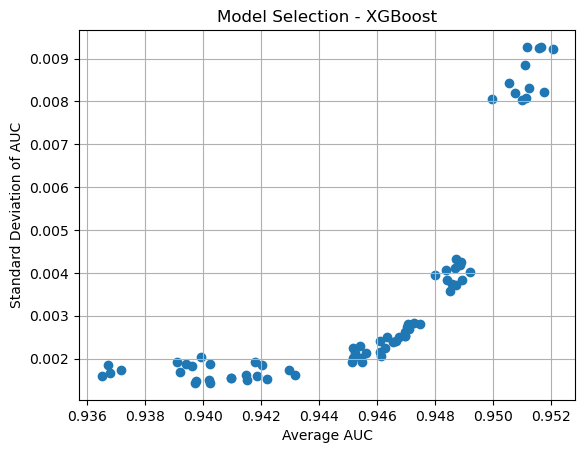

In [177]:
import matplotlib.pyplot as plt

plt.scatter(grid_results['Average AUC'], grid_results['Std AUC'])
plt.xlabel('Average AUC')
plt.ylabel('Standard Deviation of AUC')
plt.title('Model Selection - XGBoost')
plt.grid(True)
plt.show()

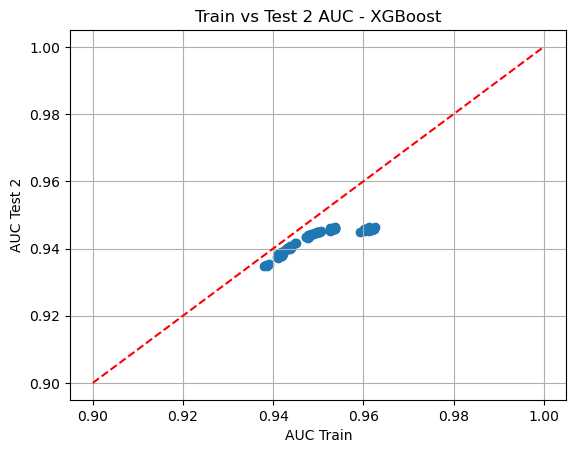

In [179]:
plt.scatter(grid_results['AUC Train'], grid_results['AUC Test 2'])
plt.plot([0.9, 1], [0.9, 1], 'r--')
plt.xlabel('AUC Train')
plt.ylabel('AUC Test 2')
plt.title('Train vs Test 2 AUC - XGBoost')
plt.grid(True)
plt.show()

In [181]:
grid_results.sort_values('Std AUC').head(5)

,Trees,LR,Subsample,% Features,Weight of Default,AUC Train,AUC Test 1,AUC Test 2,Average AUC,Std AUC
8,50.0,0.01,0.8,0.5,10.0,0.941142,0.939776,0.938278,0.939732,0.001432
1,50.0,0.01,0.5,0.5,5.0,0.941737,0.940044,0.938883,0.940221,0.001435
2,50.0,0.01,0.5,0.5,10.0,0.941185,0.939836,0.938248,0.939757,0.001470
25,100.0,0.01,0.5,0.5,5.0,0.943119,0.941281,0.940150,0.941517,0.001498
7,50.0,0.01,0.8,0.5,5.0,0.941796,0.940041,0.938795,0.940211,0.001508


In [183]:
import pickle

best_xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.01,
    max_depth=4,
    subsample=0.5,
    colsample_bytree=0.5,
    scale_pos_weight=5,
    random_state=42,
    eval_metric='logloss'
)
best_xgb.fit(X_train_s, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [185]:
# Check AUC on all three samples
auc_train = roc_auc_score(y_train, best_xgb.predict_proba(X_train_s)[:, 1])
auc_test1 = roc_auc_score(y_test1, best_xgb.predict_proba(X_test1_s)[:, 1])
auc_test2 = roc_auc_score(y_test2, best_xgb.predict_proba(X_test2_s)[:, 1])

print(f"AUC Train: {auc_train:.4f}")
print(f"AUC Test1: {auc_test1:.4f}")
print(f"AUC Test2: {auc_test2:.4f}")

# Save the model
pickle.dump(best_xgb, open("best_xgb_model.pkl", "wb"))
print("Model saved!")

AUC Train: 0.9431
AUC Test1: 0.9413
AUC Test2: 0.9402
Model saved!


In [187]:
import numpy as np

# Get predicted probabilities for all three samples
train_scores = best_xgb.predict_proba(X_train_s)[:, 1]
test1_scores = best_xgb.predict_proba(X_test1_s)[:, 1]
test2_scores = best_xgb.predict_proba(X_test2_s)[:, 1]

In [189]:
# Create score bins based on TRAIN sample only
bins = np.percentile(train_scores, [0, 25, 50, 75, 100])

# Apply same bins to all three samples
train_bins = pd.cut(train_scores, bins=bins, include_lowest=True)
test1_bins = pd.cut(test1_scores, bins=bins, include_lowest=True)
test2_bins = pd.cut(test2_scores, bins=bins, include_lowest=True)

# Calculate default rate per bin for each sample
train_dr = pd.Series(y_train).groupby(train_bins).mean()
test1_dr = pd.Series(y_test1).groupby(test1_bins).mean()
test2_dr = pd.Series(y_test2).groupby(test2_bins).mean()

/var/folders/70/fpb7f1jd16lfs40_zf7jzz7r0000gn/T/ipykernel_83145/2524650946.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_dr = pd.Series(y_train).groupby(train_bins).mean()
/var/folders/70/fpb7f1jd16lfs40_zf7jzz7r0000gn/T/ipykernel_83145/2524650946.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  test1_dr = pd.Series(y_test1).groupby(test1_bins).mean()
/var/folders/70/fpb7f1jd16lfs40_zf7jzz7r0000gn/T/ipykernel_83145/2524650946.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behav

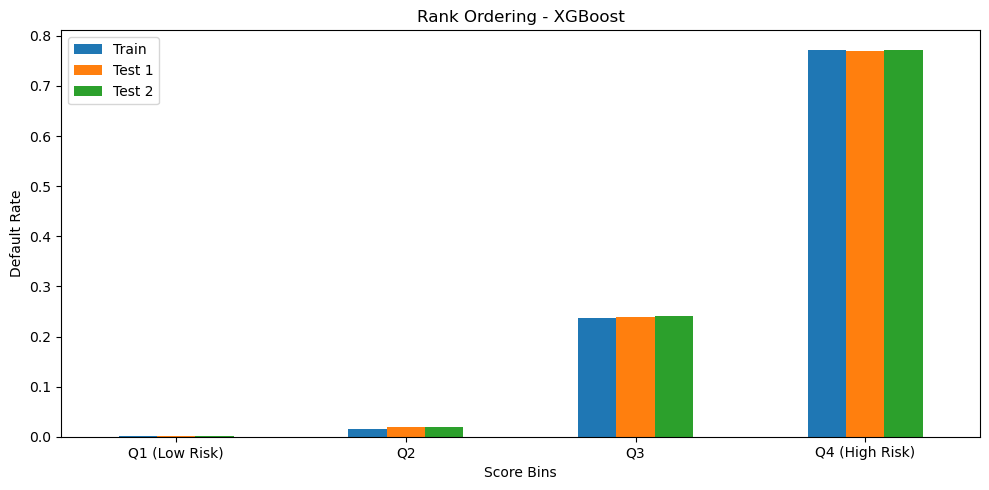

In [191]:
# Plot
rank_df = pd.DataFrame({
    'Train': train_dr.values,
    'Test 1': test1_dr.values,
    'Test 2': test2_dr.values
}, index=['Q1 (Low Risk)', 'Q2', 'Q3', 'Q4 (High Risk)'])

rank_df.plot(kind='bar', figsize=(10, 5))
plt.ylabel('Default Rate')
plt.xlabel('Score Bins')
plt.title('Rank Ordering - XGBoost')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.savefig('xgb_rank_ordering.png', dpi=150)
plt.show()

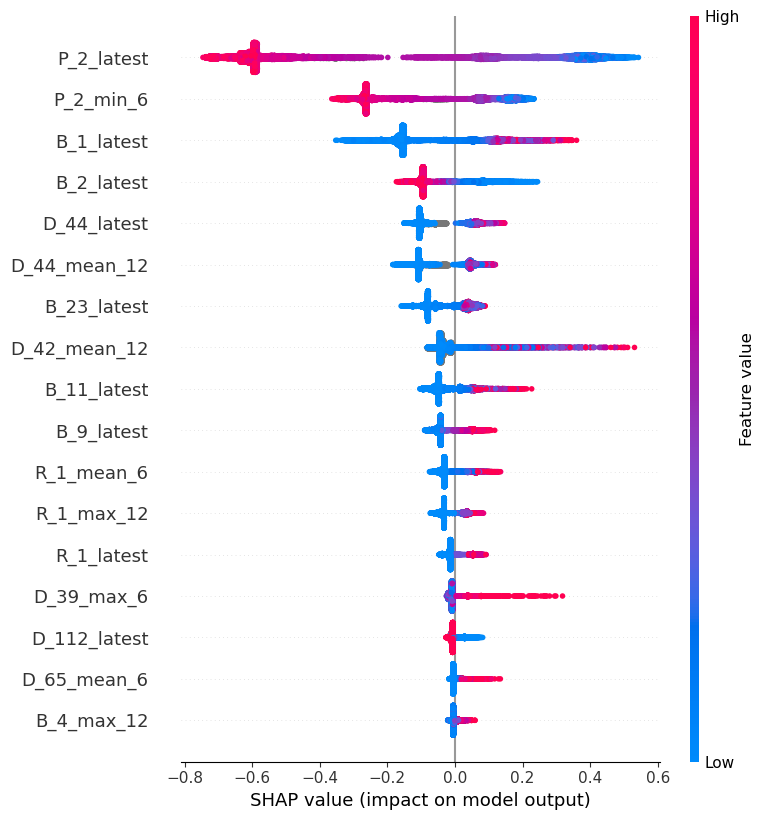

In [193]:
import shap

explainer = shap.Explainer(best_xgb)
shap_values = explainer.shap_values(X_test2_s)

# Slide 10 - Beeswarm plot
shap.summary_plot(shap_values, X_test2_s)

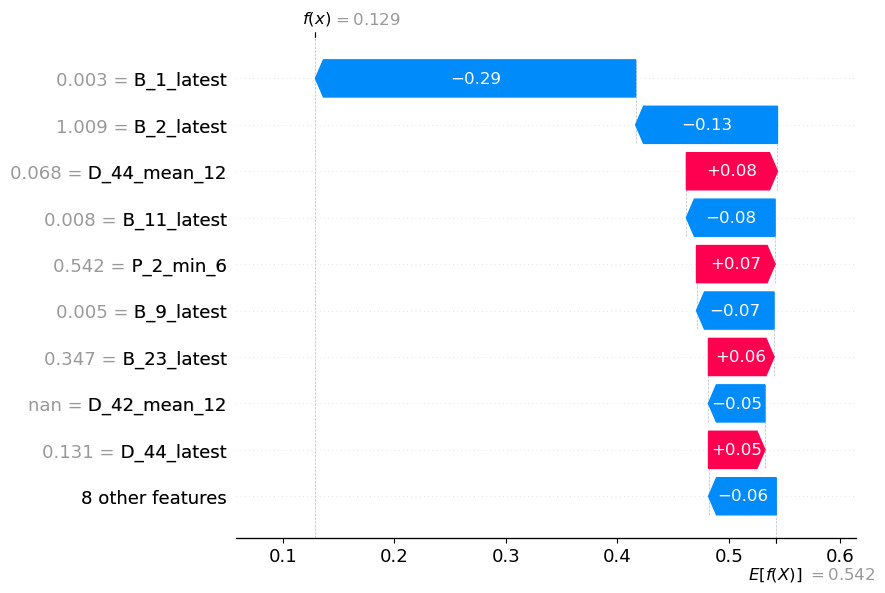

In [195]:
sample_index = 0

explanation = shap.Explanation(
    values=shap_values[sample_index],
    base_values=explainer.expected_value,
    data=X_test2_s.iloc[sample_index],
    feature_names=X_test2_s.columns.tolist()
)

shap.waterfall_plot(explanation)

In [197]:
X_train_nn = X_train_s.copy()
X_test1_nn = X_test1_s.copy()
X_test2_nn = X_test2_s.copy()

In [199]:
Q1 = X_train_nn.quantile(0.01)
Q99 = X_train_nn.quantile(0.99)

for col in selected_features:
    X_train_nn[col] = X_train_nn[col].clip(Q1[col], Q99[col])
    X_test1_nn[col] = X_test1_nn[col].clip(Q1[col], Q99[col])
    X_test2_nn[col] = X_test2_nn[col].clip(Q1[col], Q99[col])

print("Outlier treatment done")

Outlier treatment done


In [201]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_nn[selected_features] = scaler.fit_transform(X_train_nn[selected_features])
X_test1_nn[selected_features] = scaler.transform(X_test1_nn[selected_features])
X_test2_nn[selected_features] = scaler.transform(X_test2_nn[selected_features])

print("Normalization done")

Normalization done


In [203]:
X_train_nn.fillna(0, inplace=True)
X_test1_nn.fillna(0, inplace=True)
X_test2_nn.fillna(0, inplace=True)

print(f"Missing values: {X_train_nn.isna().sum().sum()}")

Missing values: 0


In [205]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import roc_auc_score

columns = ['# HL', '# Nodes', 'Activation', 'Dropout', 'Batch Size', 'AUC Train', 'AUC Test 1', 'AUC Test 2']
nn_results = pd.DataFrame(columns=columns)

i = 0
for hl in [2, 4]:
    for nodes in [4, 6]:
        for activation in ['relu', 'tanh']:
            for dropout in [0.5, 0.0]:
                for batch_size in [100, 10000]:
                    print(f"Model {i+1}/32...", end=' ')
                    
                    model = Sequential()
                    model.add(Dense(nodes, activation=activation, input_dim=X_train_nn.shape[1]))
                    if dropout > 0:
                        model.add(Dropout(dropout))
                    
                    for _ in range(hl - 1):
                        model.add(Dense(nodes, activation=activation))
                        if dropout > 0:
                            model.add(Dropout(dropout))
                    
                    model.add(Dense(1, activation='sigmoid'))
                    
                    model.compile(optimizer='adam', loss='binary_crossentropy')
                    model.fit(X_train_nn, y_train, batch_size=batch_size, epochs=20, verbose=0)
                    
                    auc_train = roc_auc_score(y_train, model.predict(X_train_nn))
                    auc_test1 = roc_auc_score(y_test1, model.predict(X_test1_nn))
                    auc_test2 = roc_auc_score(y_test2, model.predict(X_test2_nn))
                    
                    nn_results.loc[i] = [hl, nodes, activation, dropout, batch_size, auc_train, auc_test1, auc_test2]
                    i += 1
                    nn_results.to_csv('nn_grid_search.csv', index=False)

print(f"\nDone! {len(nn_results)} models trained.")

Model 1/32... 

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2008/2008 ━━━━━━━━━━━━━━━━━━━━ 0s 144us/step
431/431 ━━━━━━━━━━━━━━━━━━━━ 0s 154us/step
431/431 ━━━━━━━━━━━━━━━━━━━━ 0s 151us/step
Model 2/32... 

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2008/2008 ━━━━━━━━━━━━━━━━━━━━ 0s 146us/step
431/431 ━━━━━━━━━━━━━━━━━━━━ 0s 149us/step
431/431 ━━━━━━━━━━━━━━━━━━━━ 0s 149us/step
Model 3/32... 

...

2008/2008 ━━━━━━━━━━━━━━━━━━━━ 0s 158us/step
431/431 ━━━━━━━━━━━━━━━━━━━━ 0s 163us/step
431/431 ━━━━━━━━━━━━━━━━━━━━ 0s 156us/step
Model 31/32... 

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2008/2008 ━━━━━━━━━━━━━━━━━━━━ 0s 152us/step
431/431 ━━━━━━━━━━━━━━━━━━━━ 0s 155us/step
431/431 ━━━━━━━━━━━━━━━━━━━━ 0s 155us/step
Model 32/32... 

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2008/2008 ━━━━━━━━━━━━━━━━━━━━ 0s 152us/step
431/431 ━━━━━━━━━━━━━━━━━━━━ 0s 154us/step
431/431 ━━━━━━━━━━━━━━━━━━━━ 0s 154us/step

Done! 32 models trained.


In [207]:
nn_results = pd.read_csv('nn_grid_search.csv')
nn_results['Average AUC'] = nn_results[['AUC Train', 'AUC Test 1', 'AUC Test 2']].mean(axis=1)
nn_results['Std AUC'] = nn_results[['AUC Train', 'AUC Test 1', 'AUC Test 2']].std(axis=1)

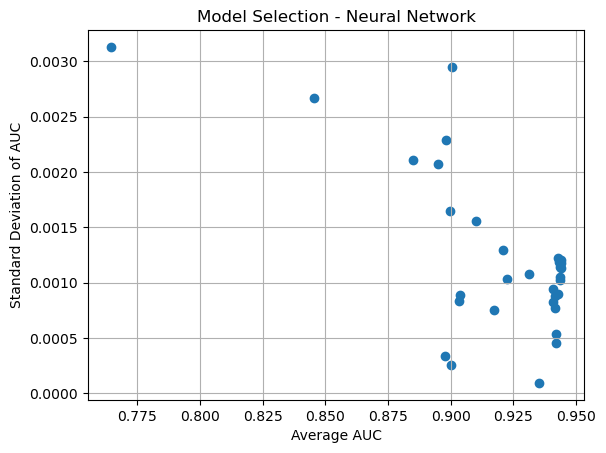

In [209]:
plt.scatter(nn_results['Average AUC'], nn_results['Std AUC'])
plt.xlabel('Average AUC')
plt.ylabel('Standard Deviation of AUC')
plt.title('Model Selection - Neural Network')
plt.grid(True)
plt.show()

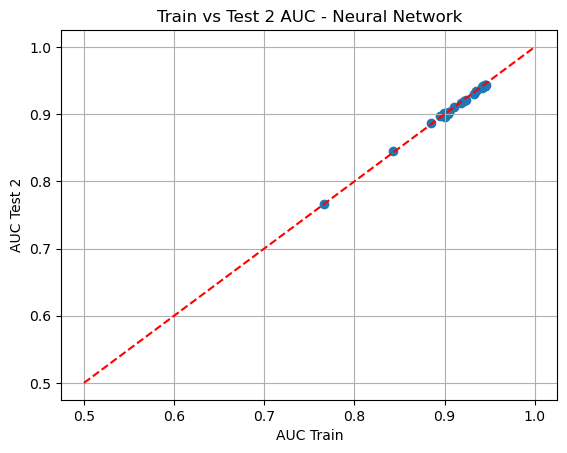

In [211]:
plt.scatter(nn_results['AUC Train'], nn_results['AUC Test 2'])
plt.plot([0.5, 1], [0.5, 1], 'r--')
plt.xlabel('AUC Train')
plt.ylabel('AUC Test 2')
plt.title('Train vs Test 2 AUC - Neural Network')
plt.grid(True)
plt.show()

In [213]:
nn_results.sort_values('Std AUC').head(5)

,# HL,# Nodes,Activation,Dropout,Batch Size,AUC Train,AUC Test 1,AUC Test 2,Average AUC,Std AUC
31,4,6,tanh,0.0,10000,0.935157,0.935047,0.934970,0.935058,0.000094
13,2,6,tanh,0.5,10000,0.899792,0.899734,0.900205,0.899910,0.000256
9,2,6,relu,0.5,10000,0.898148,0.897482,0.897904,0.897844,0.000337
24,4,6,relu,0.5,100,0.942385,0.941951,0.941473,0.941936,0.000456
0,2,4,relu,0.5,100,0.942634,0.942111,0.941565,0.942103,0.000535


In [215]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

best_nn = Sequential()

In [217]:
# Layer 1
best_nn.add(Dense(6, activation='relu', input_dim=X_train_nn.shape[1]))
best_nn.add(Dropout(0.5))

# Layer 2
best_nn.add(Dense(6, activation='relu'))
best_nn.add(Dropout(0.5))

# Layer 3
best_nn.add(Dense(6, activation='relu'))
best_nn.add(Dropout(0.5))

# Layer 4
best_nn.add(Dense(6, activation='relu'))
best_nn.add(Dropout(0.5))

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [219]:
best_nn.add(Dense(1, activation='sigmoid'))

In [221]:
best_nn.compile(optimizer='adam', loss='binary_crossentropy')
best_nn.fit(X_train_nn, y_train, batch_size=100, epochs=20, verbose=0)

auc_train = roc_auc_score(y_train, best_nn.predict(X_train_nn))
auc_test1 = roc_auc_score(y_test1, best_nn.predict(X_test1_nn))
auc_test2 = roc_auc_score(y_test2, best_nn.predict(X_test2_nn))

print(f"AUC Train: {auc_train:.4f}")
print(f"AUC Test1: {auc_test1:.4f}")
print(f"AUC Test2: {auc_test2:.4f}")

best_nn.save('best_nn_model.keras')
print("Model saved!")

2008/2008 ━━━━━━━━━━━━━━━━━━━━ 0s 154us/step
431/431 ━━━━━━━━━━━━━━━━━━━━ 0s 158us/step
431/431 ━━━━━━━━━━━━━━━━━━━━ 0s 159us/step
AUC Train: 0.9301
AUC Test1: 0.9301
AUC Test2: 0.9288
Model saved!


In [223]:
train_scores_nn = best_nn.predict(X_train_nn).reshape(-1)
test1_scores_nn = best_nn.predict(X_test1_nn).reshape(-1)
test2_scores_nn = best_nn.predict(X_test2_nn).reshape(-1)

2008/2008 ━━━━━━━━━━━━━━━━━━━━ 0s 157us/step
431/431 ━━━━━━━━━━━━━━━━━━━━ 0s 161us/step
431/431 ━━━━━━━━━━━━━━━━━━━━ 0s 165us/step


In [225]:
bins_nn = np.percentile(train_scores_nn, [0, 25, 50, 75, 100])

train_bins_nn = pd.cut(train_scores_nn, bins=bins_nn, include_lowest=True)
test1_bins_nn = pd.cut(test1_scores_nn, bins=bins_nn, include_lowest=True)
test2_bins_nn = pd.cut(test2_scores_nn, bins=bins_nn, include_lowest=True)

In [227]:
train_dr_nn = pd.Series(y_train).groupby(train_bins_nn).mean()
test1_dr_nn = pd.Series(y_test1).groupby(test1_bins_nn).mean()
test2_dr_nn = pd.Series(y_test2).groupby(test2_bins_nn).mean()

/var/folders/70/fpb7f1jd16lfs40_zf7jzz7r0000gn/T/ipykernel_83145/1884265878.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_dr_nn = pd.Series(y_train).groupby(train_bins_nn).mean()
/var/folders/70/fpb7f1jd16lfs40_zf7jzz7r0000gn/T/ipykernel_83145/1884265878.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  test1_dr_nn = pd.Series(y_test1).groupby(test1_bins_nn).mean()
/var/folders/70/fpb7f1jd16lfs40_zf7jzz7r0000gn/T/ipykernel_83145/1884265878.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curr

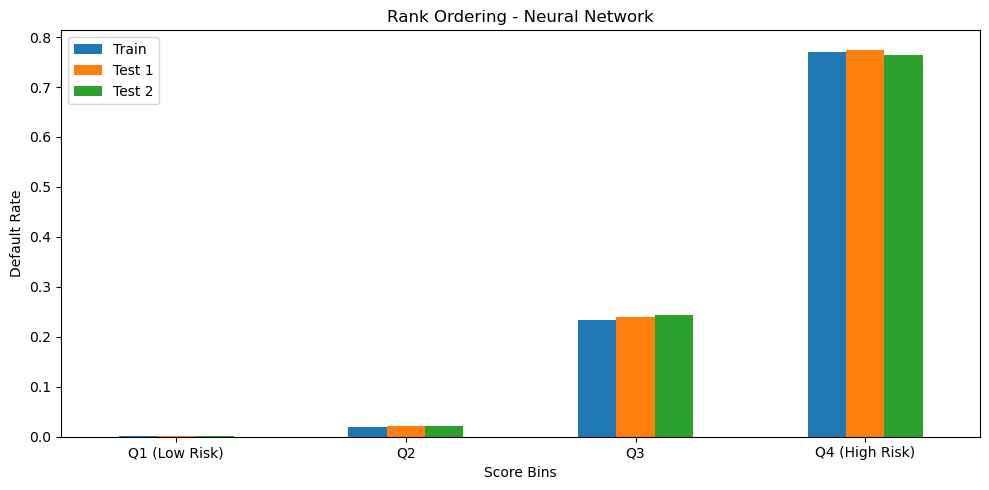

In [229]:
rank_nn = pd.DataFrame({
    'Train': train_dr_nn.values,
    'Test 1': test1_dr_nn.values,
    'Test 2': test2_dr_nn.values
}, index=['Q1 (Low Risk)', 'Q2', 'Q3', 'Q4 (High Risk)'])

rank_nn.plot(kind='bar', figsize=(10, 5))
plt.ylabel('Default Rate')
plt.xlabel('Score Bins')
plt.title('Rank Ordering - Neural Network')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.savefig('nn_rank_ordering.png', dpi=150)
plt.show()

In [231]:
def strategy(data, target, model_pred, bal, spend, threshold):
    accepted = data[data[model_pred] < threshold]
    default_rate = accepted[target].mean()
    
    non_defaulted = accepted[accepted[target] == 0]
    revenue = (non_defaulted[bal] * 0.02 + non_defaulted[spend] * 0.001).sum() * 12
    
    return default_rate, revenue

In [233]:
# Get XGBoost predictions on train data
train_pred = best_xgb.predict_proba(X_train_s)[:, 1]

# Build input dataframe
input_data = pd.DataFrame()
input_data['target'] = y_train.values
input_data['pred'] = train_pred
input_data['bal'] = features_df.loc[X_train_s.index, 'B_1_mean_6'].values
input_data['spend'] = features_df.loc[X_train_s.index, 'S_3_mean_6'].values

input_data.fillna(0, inplace=True)
print(input_data.shape)
input_data.head()

(64248, 4)


,target,pred,bal,spend
0,0,0.266260,0.037719,0.050926
1,0,0.268989,0.025729,0.343027
2,1,0.772640,0.406639,0.244764
3,1,0.601411,0.169999,0.434959
4,1,0.853363,0.177029,0.291888


In [235]:
print(f"{'Threshold':<12} {'Default Rate':<15} {'Revenue':>15}")
print("-" * 45)

for t in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60, 0.70]:
    dr, rev = strategy(input_data, 'target', 'pred', 'bal', 'spend', t)
    print(f"{t:<12.2f} {dr:<15.4f} {rev:>15,.2f}")

Threshold    Default Rate            Revenue
---------------------------------------------
0.05         nan                        0.00
0.10         nan                        0.00
0.15         nan                        0.00
0.20         nan                        0.00
0.25         nan                        0.00
0.30         0.0047                   180.67
0.40         0.0098                   273.58
0.50         0.0163                   364.55
0.60         0.0287                   456.48
0.70         0.0542                   601.57


In [237]:
print(f"{'Threshold':<12} {'Default Rate':<15} {'Accepted %':<12} {'Revenue':>15}")
print("-" * 58)

total = len(input_data)
for t in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]:
    dr, rev = strategy(input_data, 'target', 'pred', 'bal', 'spend', t)
    accepted = len(input_data[input_data['pred'] < t])
    pct = accepted / total * 100
    print(f"{t:<12.2f} {dr:<15.4f} {pct:<12.1f} {rev:>15,.2f}")

Threshold    Default Rate    Accepted %           Revenue
----------------------------------------------------------
0.30         0.0047          40.3                  180.67
0.35         0.0072          47.0                  230.20
0.40         0.0098          51.5                  273.58
0.45         0.0130          54.9                  320.90
0.50         0.0163          57.4                  364.55
0.55         0.0218          60.0                  405.57
0.60         0.0287          62.7                  456.48
0.65         0.0390          65.7                  520.98
0.70         0.0542          69.3                  601.57
0.75         0.0799          74.2                  706.64
0.80         0.1381          83.5                  892.40
0.85         0.2387          97.6                1,001.31
0.90         0.2565          100.0               1,002.54


In [239]:
# Get predictions for test samples too
test1_pred = best_xgb.predict_proba(X_test1_s)[:, 1]
test2_pred = best_xgb.predict_proba(X_test2_s)[:, 1]

test1_data = pd.DataFrame()
test1_data['target'] = y_test1.values
test1_data['pred'] = test1_pred
test1_data['bal'] = features_df.loc[X_test1_s.index, 'B_1_mean_6'].values
test1_data['spend'] = features_df.loc[X_test1_s.index, 'S_3_mean_6'].values
test1_data.fillna(0, inplace=True)

test2_data = pd.DataFrame()
test2_data['target'] = y_test2.values
test2_data['pred'] = test2_pred
test2_data['bal'] = features_df.loc[X_test2_s.index, 'B_1_mean_6'].values
test2_data['spend'] = features_df.loc[X_test2_s.index, 'S_3_mean_6'].values
test2_data.fillna(0, inplace=True)

# Test both strategies on all samples
print(f"{'Strategy':<15} {'Sample':<10} {'Default Rate':<15} {'Revenue':>12}")
print("-" * 55)
for name, data in [('Train', input_data), ('Test 1', test1_data), ('Test 2', test2_data)]:
    dr1, rev1 = strategy(data, 'target', 'pred', 'bal', 'spend', 0.50)
    dr2, rev2 = strategy(data, 'target', 'pred', 'bal', 'spend', 0.75)
    print(f"{'Conservative':<15} {name:<10} {dr1:<15.4f} {rev1:>12,.2f}")
    print(f"{'Aggressive':<15} {name:<10} {dr2:<15.4f} {rev2:>12,.2f}")
    print()

Strategy        Sample     Default Rate         Revenue
-------------------------------------------------------
Conservative    Train      0.0163                364.55
Aggressive      Train      0.0799                706.64

Conservative    Test 1     0.0194                 78.82
Aggressive      Test 1     0.0824                154.77

Conservative    Test 2     0.0178                 84.64
Aggressive      Test 2     0.0827                156.17

